# 🧹 Task 2: Data Cleaning & Preprocessing
---
**Objective:** Load a real-world dataset, identify and handle missing values, remove duplicates, fix data types, detect/treat outliers, normalize/standardize numerical features, and save a clean, analysis-ready CSV.

**Dataset Used:** [Titanic Dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) — a classic ML benchmark with realistic data quality issues.

**Direct CSV URL (for Google Colab):**
```
https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
```

---
**Author:** Data Science Lab  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn


## 🔧 Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
import warnings, os
from datetime import datetime
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

OUTPUT_DIR = "cleaned_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Libraries ready!")
print(f"📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ Libraries ready!
📅 2026-05-30 07:42:38


## 📥 Step 2: Load Dataset

In [2]:
CSV_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(CSV_URL)
print(f"✅ Loaded dataset  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n📋 Columns:", df.columns.tolist())
df.head(10)


✅ Loaded dataset  →  891 rows × 12 columns

📋 Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 🔍 Step 3: Initial Data Audit

In [3]:
print("=" * 60)
print("           INITIAL DATA AUDIT REPORT")
print("=" * 60)

# Shape
print(f"\n📐 Shape         : {df.shape[0]:,} rows × {df.shape[1]} cols")

# Data types
print("\n📊 Data Types:")
print(df.dtypes.to_string())

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("\n❓ Missing Values:")
print(missing_df.to_string())

# Duplicates
print(f"\n♻️  Duplicate Rows : {df.duplicated().sum()}")

# Unique counts for categorical
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("\n🔤 Categorical Unique Counts:")
for c in cat_cols:
    print(f"   {c:<15}: {df[c].nunique()} unique values")


           INITIAL DATA AUDIT REPORT

📐 Shape         : 891 rows × 12 cols

📊 Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object

❓ Missing Values:
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22

♻️  Duplicate Rows : 0

🔤 Categorical Unique Counts:
   Name           : 891 unique values
   Sex            : 2 unique values
   Ticket         : 681 unique values
   Cabin          : 147 unique values
   Embarked       : 3 unique values


## 📊 Step 4: Visualize Missing Data

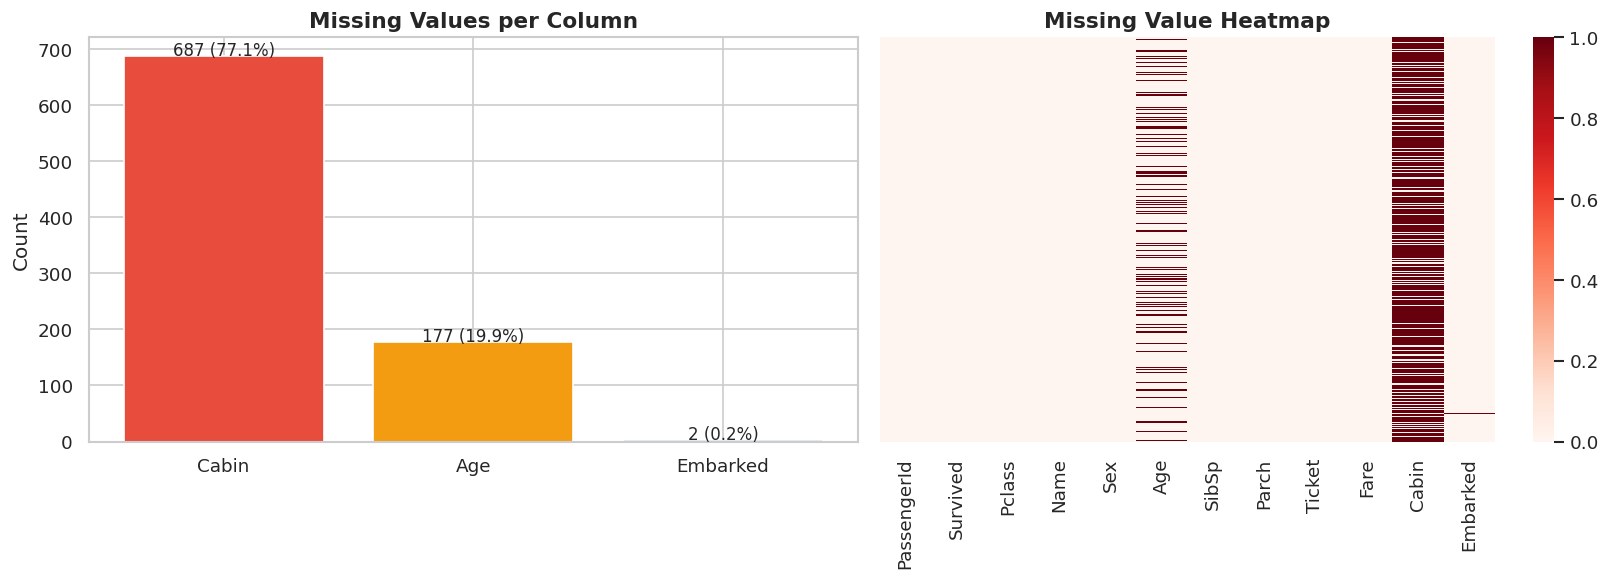

📊 Missing value chart saved.


In [4]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(missing_data.index, missing_data.values,
                   color=["#E74C3C","#F39C12","#3498DB"])
axes[0].set_title("Missing Values per Column", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for bar, val in zip(bars, missing_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"{val} ({val/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap="Reds", ax=axes[1])
axes[1].set_title("Missing Value Heatmap", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_missing_values.png"), bbox_inches="tight")
plt.show()
print("📊 Missing value chart saved.")


## 🔄 Step 5: Handle Missing Values

In [5]:
df_clean = df.copy()

# ── Age: impute with median grouped by Pclass & Sex ──────────────────
df_clean["Age"] = df_clean.groupby(["Pclass","Sex"])["Age"] \
                          .transform(lambda x: x.fillna(x.median()))

# ── Cabin: high missingness (77%) → encode presence/absence ──────────
df_clean["Has_Cabin"] = df_clean["Cabin"].notna().astype(int)
df_clean.drop(columns=["Cabin"], inplace=True)

# ── Embarked: fill 2 missing rows with mode ──────────────────────────
df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0], inplace=True)

# ── Fare: no missing, but standardise column name ────────────────────

print("✅ Missing values handled:")
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("   🎉 No missing values remain!")
else:
    print(remaining)

print(f"\n📐 Shape after handling missing: {df_clean.shape}")


✅ Missing values handled:
   🎉 No missing values remain!

📐 Shape after handling missing: (891, 12)


## 🗑️ Step 6: Remove Duplicates & Irrelevant Columns

In [6]:
dups_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f"♻️  Removed {dups_before} duplicate row(s).")

# Drop high-cardinality / non-informative columns
drop_cols = ["PassengerId", "Name", "Ticket"]
df_clean.drop(columns=drop_cols, inplace=True)
print(f"🗑️  Dropped columns: {drop_cols}")
print(f"📐 Shape: {df_clean.shape}")


♻️  Removed 0 duplicate row(s).
🗑️  Dropped columns: ['PassengerId', 'Name', 'Ticket']
📐 Shape: (891, 9)


## ⚙️ Step 7: Feature Engineering & Type Fixes

In [7]:
# Fix dtypes
df_clean["Survived"] = df_clean["Survived"].astype(int)
df_clean["Pclass"]   = df_clean["Pclass"].astype("category")

# Family size feature
df_clean["Family_Size"]   = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["Is_Alone"]      = (df_clean["Family_Size"] == 1).astype(int)

# Age groups
df_clean["Age_Group"] = pd.cut(df_clean["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child","Teen","Young Adult","Adult","Senior"])

print("✅ New features added: Family_Size, Is_Alone, Age_Group")
print(f"📐 Shape: {df_clean.shape}")
df_clean.head()


✅ New features added: Family_Size, Is_Alone, Age_Group
📐 Shape: (891, 12)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Family_Size,Is_Alone,Age_Group
0,0,3,male,22.0,1,0,7.2500,S,0,2,0,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,1,2,0,Adult
2,1,3,female,26.0,0,0,7.9250,S,0,1,1,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,1,2,0,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,0,1,1,Young Adult


## 🚨 Step 8: Outlier Detection & Treatment

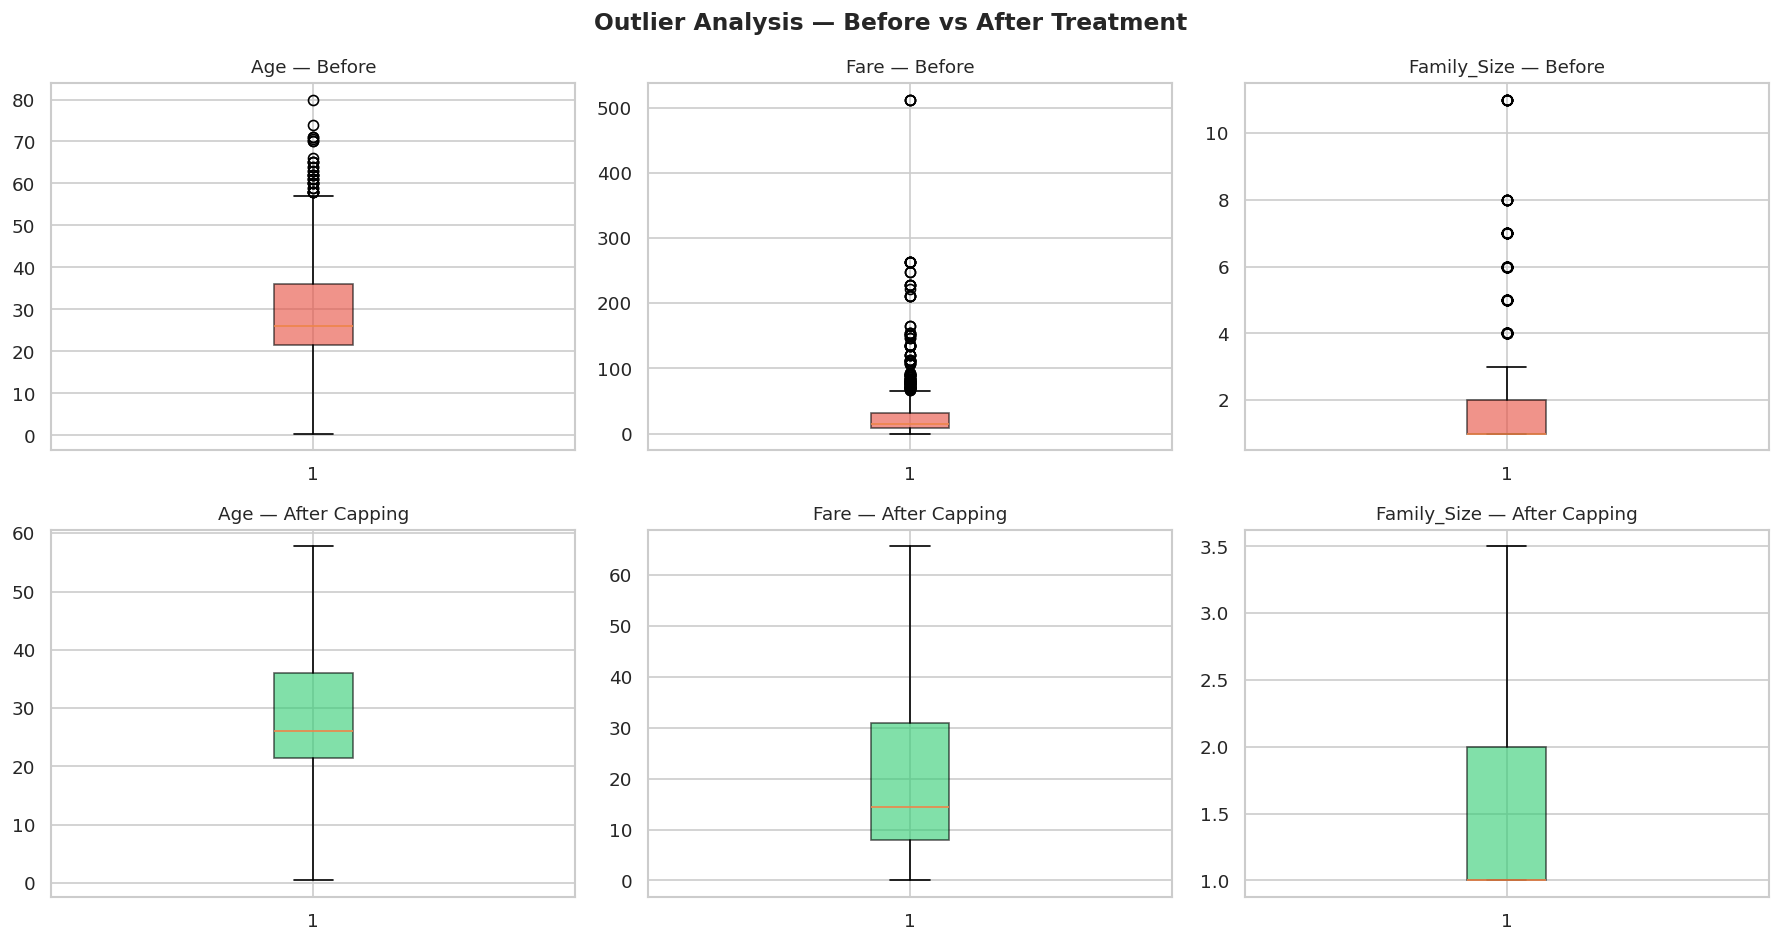

📊 Outlier chart saved.


In [8]:
numeric_cols = ["Age","Fare","Family_Size"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Outlier Analysis — Before vs After Treatment", fontsize=14, fontweight="bold")

for i, col in enumerate(numeric_cols):
    # Before
    axes[0, i].boxplot(df_clean[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor="#E74C3C", alpha=0.6))
    axes[0, i].set_title(f"{col} — Before", fontsize=11)

    # IQR capping
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

    # After
    axes[1, i].boxplot(df_clean[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor="#2ECC71", alpha=0.6))
    axes[1, i].set_title(f"{col} — After Capping", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_outliers.png"), bbox_inches="tight")
plt.show()
print("📊 Outlier chart saved.")


## 🔤 Step 9: Encode Categorical Variables

In [9]:
le = LabelEncoder()

# Ordinal / binary
df_clean["Sex_Enc"]       = le.fit_transform(df_clean["Sex"])          # male=1, female=0
df_clean["Embarked_Enc"]  = le.fit_transform(df_clean["Embarked"])
df_clean["Age_Group_Enc"] = le.fit_transform(df_clean["Age_Group"].astype(str))

# One-hot for Pclass
pclass_dummies = pd.get_dummies(df_clean["Pclass"], prefix="Pclass", drop_first=True)
df_clean = pd.concat([df_clean, pclass_dummies], axis=1)

print("✅ Categorical encoding complete.")
print("   Label-encoded : Sex, Embarked, Age_Group")
print("   One-hot       : Pclass")
print(f"📐 Shape: {df_clean.shape}")


✅ Categorical encoding complete.
   Label-encoded : Sex, Embarked, Age_Group
   One-hot       : Pclass
📐 Shape: (891, 17)


## 📏 Step 10: Normalize & Standardize Numerical Features

In [12]:
scale_cols = ["Age", "Fare", "Family_Size"]

# Min-Max Normalization  → [0, 1]
minmax = MinMaxScaler()
df_clean[[c + "_norm" for c in scale_cols]] = minmax.fit_transform(df_clean[scale_cols])

# Z-score Standardization → mean=0, std=1
std_scaler = StandardScaler()
df_clean[[c + "_std" for c in scale_cols]] = std_scaler.fit_transform(df_clean[scale_cols])

print("✅ Scaling applied:")
print("   Min-Max normalized  →", [c+"_norm" for c in scale_cols])
print("   Z-score standardized →", [c+"_std"  for c in scale_cols])

# Show comparison
comp_data = []
for col in scale_cols:
    original_stats = df_clean[col].agg(["mean", "std"])
    normalized_stats = df_clean[col + "_norm"].agg(["mean", "std"])
    standardized_stats = df_clean[col + "_std"].agg(["mean", "std"])

    comp_data.append({
        "Metric": col,
        "Original (mean/std)": f"{original_stats['mean']:.2f} / {original_stats['std']:.2f}",
        "Normalized (mean/std)": f"{normalized_stats['mean']:.2f} / {normalized_stats['std']:.2f}",
        "Standardized (mean/std)": f"{standardized_stats['mean']:.2f} / {standardized_stats['std']:.2f}",
    })

comp = pd.DataFrame(comp_data).set_index("Metric")
print("\n📊 Scaling Comparison:")
print(comp.to_string())

✅ Scaling applied:
   Min-Max normalized  → ['Age_norm', 'Fare_norm', 'Family_Size_norm']
   Z-score standardized → ['Age_std', 'Fare_std', 'Family_Size_std']

📊 Scaling Comparison:
            Original (mean/std) Normalized (mean/std) Standardized (mean/std)
Metric                                                                       
Age               28.89 / 12.73           0.50 / 0.22             0.00 / 1.00
Fare              24.05 / 20.48           0.37 / 0.31             0.00 / 1.00
Family_Size         1.66 / 0.91           0.27 / 0.37            -0.00 / 1.00


## 📊 Step 11: Post-Cleaning Visualizations

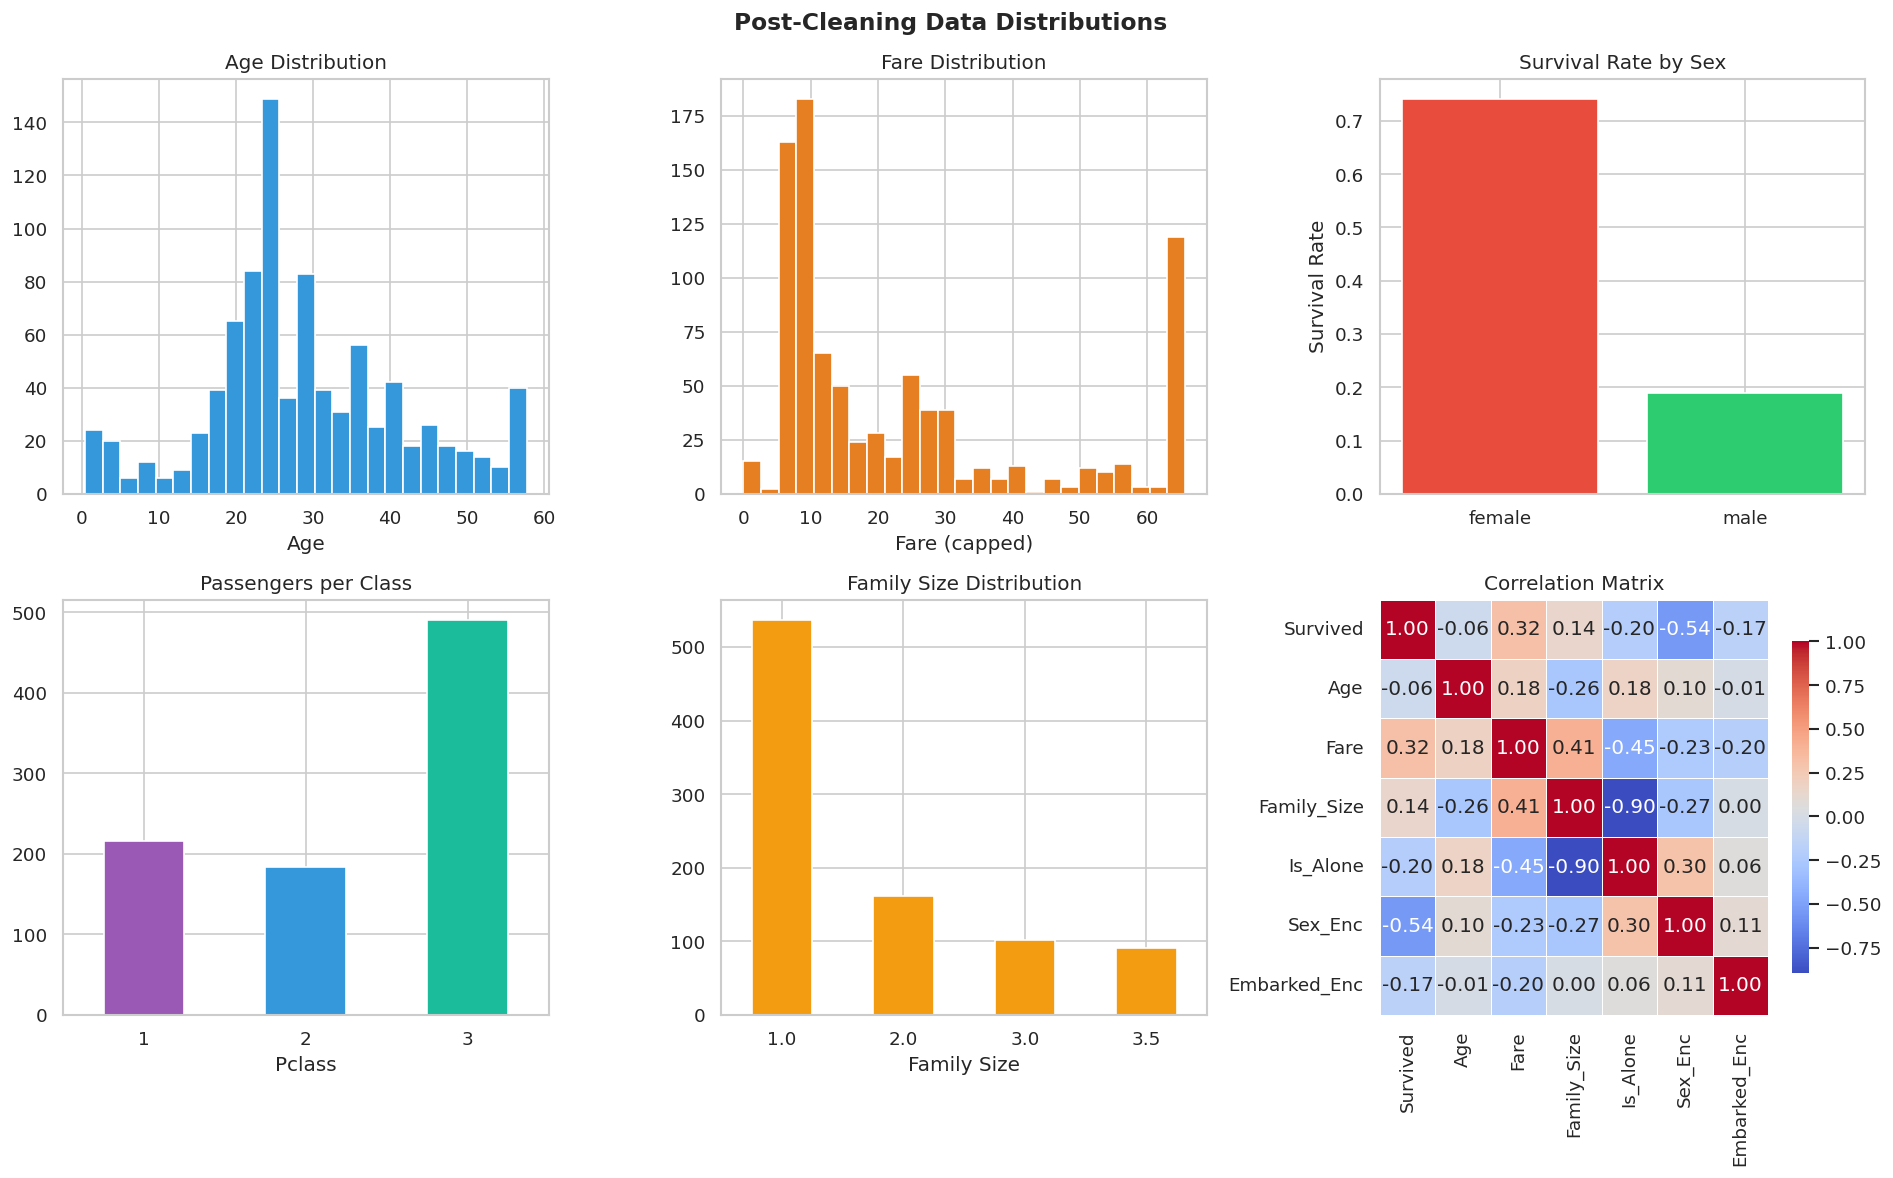

📊 Post-cleaning visualization saved.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Post-Cleaning Data Distributions", fontsize=14, fontweight="bold")

# Age distribution
axes[0,0].hist(df_clean["Age"], bins=25, color="#3498DB", edgecolor="white")
axes[0,0].set_title("Age Distribution"); axes[0,0].set_xlabel("Age")

# Fare distribution
axes[0,1].hist(df_clean["Fare"], bins=25, color="#E67E22", edgecolor="white")
axes[0,1].set_title("Fare Distribution"); axes[0,1].set_xlabel("Fare (capped)")

# Survival by Sex
survival_sex = df_clean.groupby("Sex")["Survived"].mean().reset_index()
axes[0,2].bar(survival_sex["Sex"], survival_sex["Survived"],
              color=["#E74C3C","#2ECC71"], edgecolor="white")
axes[0,2].set_title("Survival Rate by Sex"); axes[0,2].set_ylabel("Survival Rate")

# Pclass counts
df_clean["Pclass"].value_counts().sort_index().plot(kind="bar", ax=axes[1,0],
    color=["#9B59B6","#3498DB","#1ABC9C"], edgecolor="white", rot=0)
axes[1,0].set_title("Passengers per Class"); axes[1,0].set_xlabel("Pclass")

# Family size distribution
df_clean["Family_Size"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1],
    color="#F39C12", edgecolor="white", rot=0)
axes[1,1].set_title("Family Size Distribution"); axes[1,1].set_xlabel("Family Size")

# Correlation heatmap
num_cols = ["Survived","Age","Fare","Family_Size","Is_Alone","Sex_Enc","Embarked_Enc"]
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1,2],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1,2].set_title("Correlation Matrix")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_post_cleaning_distributions.png"), bbox_inches="tight")
plt.show()
print("📊 Post-cleaning visualization saved.")


## 💾 Step 12: Save Cleaned Dataset

In [14]:
csv_out = os.path.join(OUTPUT_DIR, "titanic_cleaned.csv")
df_clean.to_csv(csv_out, index=False)
print(f"✅ Cleaned CSV saved → {csv_out}")
print(f"   Shape  : {df_clean.shape}")
print(f"   Size   : {os.path.getsize(csv_out)/1024:.1f} KB")

print("\n📋 Final Columns:")
for col in df_clean.columns:
    print(f"   • {col}")


✅ Cleaned CSV saved → cleaned_data/titanic_cleaned.csv
   Shape  : (891, 23)
   Size   : 141.4 KB

📋 Final Columns:
   • Survived
   • Pclass
   • Sex
   • Age
   • SibSp
   • Parch
   • Fare
   • Embarked
   • Has_Cabin
   • Family_Size
   • Is_Alone
   • Age_Group
   • Sex_Enc
   • Embarked_Enc
   • Age_Group_Enc
   • Pclass_2
   • Pclass_3
   • Age_norm
   • Fare_norm
   • Family_Size_norm
   • Age_std
   • Fare_std
   • Family_Size_std


## 📋 Step 13: Final Cleaning Report

In [15]:
print("=" * 65)
print("             DATA CLEANING — FINAL REPORT")
print("=" * 65)
print(f"  Original shape          : {df.shape}")
print(f"  Cleaned shape           : {df_clean.shape}")
print(f"  Missing values handled  : Age (median), Cabin→Has_Cabin, Embarked (mode)")
print(f"  Duplicates removed      : {df.duplicated().sum()}")
print(f"  Columns dropped         : PassengerId, Name, Ticket, Cabin")
print(f"  New features created    : Family_Size, Is_Alone, Age_Group, Has_Cabin")
print(f"  Encoding                : Sex, Embarked (Label) | Pclass (One-Hot)")
print(f"  Outlier treatment       : IQR capping on Age, Fare, Family_Size")
print(f"  Scaling applied         : Min-Max + Z-score on numeric columns")
print(f"  Remaining null values   : {df_clean.isnull().sum().sum()}")
print("=" * 65)
print("✅ Task 2 — Data Cleaning COMPLETE")


             DATA CLEANING — FINAL REPORT
  Original shape          : (891, 12)
  Cleaned shape           : (891, 23)
  Missing values handled  : Age (median), Cabin→Has_Cabin, Embarked (mode)
  Duplicates removed      : 0
  Columns dropped         : PassengerId, Name, Ticket, Cabin
  New features created    : Family_Size, Is_Alone, Age_Group, Has_Cabin
  Encoding                : Sex, Embarked (Label) | Pclass (One-Hot)
  Outlier treatment       : IQR capping on Age, Fare, Family_Size
  Scaling applied         : Min-Max + Z-score on numeric columns
  Remaining null values   : 0
✅ Task 2 — Data Cleaning COMPLETE


---
## 📝 Task 2 Summary

| Step | Action |
|------|--------|
| **Load** | Titanic CSV from public GitHub URL |
| **Audit** | Shape, dtypes, missing values, duplicates |
| **Missing Values** | Age→grouped median; Cabin→binary; Embarked→mode |
| **Outliers** | IQR capping on Age, Fare, Family_Size |
| **Feature Engineering** | Family_Size, Is_Alone, Age_Group, Has_Cabin |
| **Encoding** | LabelEncoder + OneHotEncoder |
| **Scaling** | MinMaxScaler (0–1) + StandardScaler (z-score) |
| **Output** | `titanic_cleaned.csv` — analysis-ready |

> ✅ **Task 2 Complete** — Dataset cleaned, enriched, encoded, and normalized.
